In [4]:
# --- Imports ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
import warnings # To manage warnings if needed

# Ignore specific warnings if they become noisy (optional)
# warnings.filterwarnings('ignore', category=FutureWarning)
# warnings.filterwarnings('ignore', category=UserWarning)

print("Libraries imported.")

Libraries imported.


In [5]:

# --- Setup Project Path ---
# Add the project root directory ('AgenticFC888') to the Python path
# Assumes this notebook is in 'AgenticFC888/models/notebooks/'
try:
    # Get the directory of the current notebook
    NOTEBOOK_DIR = os.path.abspath(os.path.dirname('')) # This works well in Jupyter Lab/Notebook
    # Go up two levels (from notebooks -> models -> AgenticFC888)
    PROJECT_ROOT = os.path.dirname(os.path.dirname(NOTEBOOK_DIR))
    print(f"Project Root detected as: {PROJECT_ROOT}")

    if PROJECT_ROOT not in sys.path:
        print(f"Adding project root to sys.path.")
        sys.path.append(PROJECT_ROOT)

    # Verify imports from your project structure (optional)
    # from models.utils.config import PredictionConfig
    # print("Successfully imported a custom module.")

except NameError:
     # Fallback if running in an environment where __file__ or getcwd behaves differently
     # Manually set the project root if needed
     PROJECT_ROOT = '/Users/barroca888/Downloads/Agenticfc/AgenticFC888' # <-- SET MANUALLY IF NEEDED
     print(f"Using manually set PROJECT_ROOT: {PROJECT_ROOT}")
     if PROJECT_ROOT not in sys.path:
         sys.path.append(PROJECT_ROOT)
except Exception as e:
    print(f"Error setting up project path: {e}")
    print("Please verify the notebook's location relative to the project root.")


Project Root detected as: /Users/barroca888/Downloads/Agenticfc/AgenticFC888
Adding project root to sys.path.


In [6]:

# --- Configuration ---
# Define paths relative to the project root

# CHOOSE WHICH MODEL'S RESULTS TO ANALYZE:
# Make sure the filename matches exactly what predict_pipeline created
EVAL_CSV_FILENAME = 'predictions_no_odds_latest.csv'
# EVAL_CSV_FILENAME = 'predictions_with_odds_latest.csv'
# Or use 'predictions_eval_*.csv' if you renamed them

# --- CORRECTED PATH CONSTRUCTION ---
# Path should be: AgenticFC888 / models / data / outputs / predictions / filename.csv
EVAL_CSV_PATH = os.path.join(PROJECT_ROOT, 'models', 'data', 'outputs', 'predictions', EVAL_CSV_FILENAME)
# ---------------------------------

print(f"Attempting to load evaluation data from: {EVAL_CSV_PATH}")

# --- Load Data ---
try:
    df_eval = pd.read_csv(EVAL_CSV_PATH)
    print(f"\nData loaded successfully. Shape: {df_eval.shape}")
    print("Sample Data:")
    display(df_eval.head()) # Use display() in notebooks for better table formatting
    print("\nData Info:")
    df_eval.info()
except FileNotFoundError:
    print(f"ERROR: Evaluation file not found at {EVAL_CSV_PATH}")
    print("Please ensure the predict_pipeline ran correctly and check the path and filename.")
    # Stop execution or handle appropriately
    # raise SystemExit("Evaluation file missing.")
except Exception as e:
    print(f"An error occurred loading the CSV: {e}")
    # raise SystemExit("Failed to load data.")



Attempting to load evaluation data from: /Users/barroca888/Downloads/Agenticfc/AgenticFC888/models/data/outputs/predictions/predictions_no_odds_latest.csv

Data loaded successfully. Shape: (874648, 9)
Sample Data:


,MatchID,HomeTeam,AwayTeam,Rank,Outcome,Probability,FTHG,FTAG,FTR
0,20100730_StandardLiege_ZulteWaregem,Standard Liege,Zulte Waregem,1,[Over 1.5],0.748998,1,1,D
1,20100730_StandardLiege_ZulteWaregem,Standard Liege,Zulte Waregem,2,[Home Win or Away Win],0.744101,1,1,D
2,20100730_StandardLiege_ZulteWaregem,Standard Liege,Zulte Waregem,3,[Under 3.5],0.716923,1,1,D
3,20100730_StandardLiege_ZulteWaregem,Standard Liege,Zulte Waregem,4,[Home Win or Draw],0.692920,1,1,D
4,20100730_StandardLiege_ZulteWaregem,Standard Liege,Zulte Waregem,5,[Goals 2-4],0.613813,1,1,D



Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 874648 entries, 0 to 874647
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   MatchID      874648 non-null  object 
 1   HomeTeam     874648 non-null  object 
 2   AwayTeam     874648 non-null  object 
 3   Rank         874648 non-null  int64  
 4   Outcome      874648 non-null  object 
 5   Probability  874648 non-null  float64
 6   FTHG         874648 non-null  int64  
 7   FTAG         874648 non-null  int64  
 8   FTR          874648 non-null  object 
dtypes: float64(1), int64(3), object(5)
memory usage: 60.1+ MB


In [7]:

# Define the function to check correctness
def is_prediction_correct(row):
    """Checks if a prediction row matches the actual outcome."""
    outcome = row['Outcome']
    fthg = row['FTHG']
    ftag = row['FTAG']
    ftr = row['FTR']

    # Handle cases where actual results might be missing
    if pd.isna(fthg) or pd.isna(ftag) or pd.isna(ftr):
        return np.nan # Cannot evaluate

    # Ensure goals are numeric for comparison
    try:
        fthg = float(fthg)
        ftag = float(ftag)
    except (ValueError, TypeError):
         return np.nan # Cannot evaluate if goals aren't numeric

    total_goals = fthg + ftag

    # --- Check Singles ---
    if outcome == "[Home Win]": return ftr == 'H'
    if outcome == "[Draw]": return ftr == 'D'
    if outcome == "[Away Win]": return ftr == 'A'
    if outcome == "[Home Win or Draw]": return ftr in ['H', 'D']
    if outcome == "[Away Win or Draw]": return ftr in ['A', 'D']
    if outcome == "[Home Win or Away Win]": return ftr in ['H', 'A']
    if outcome == "[Over 0.5]": return total_goals > 0.5
    if outcome == "[Under 0.5]": return total_goals < 0.5
    if outcome == "[Over 1.5]": return total_goals > 1.5
    if outcome == "[Under 1.5]": return total_goals < 1.5
    if outcome == "[Over 2.5]": return total_goals > 2.5
    if outcome == "[Under 2.5]": return total_goals < 2.5
    if outcome == "[Over 3.5]": return total_goals > 3.5
    if outcome == "[Under 3.5]": return total_goals < 3.5
    if outcome == "[Over 4.5]": return total_goals > 4.5
    if outcome == "[Under 4.5]": return total_goals < 4.5
    if outcome == "[BTTS Yes]": return fthg > 0 and ftag > 0
    if outcome == "[BTTS No]": return fthg == 0 or ftag == 0
    if outcome == "[Goals 0-1]": return total_goals <= 1
    if outcome == "[Goals 2-3]": return total_goals in [2, 3]
    if outcome == "[Goals 2-4]": return total_goals in [2, 3, 4]
    if outcome == "[Goals 3+]": return total_goals >= 3

    # --- Check Duals (Requires careful parsing) ---
    if ' + ' in outcome:
        # Create a temporary copy Series to avoid modifying the original row during recursion
        temp_row = row.copy()
        parts = outcome[1:-1].split(' + ') # Remove brackets and split
        if len(parts) == 2:
            part1_outcome = "[" + parts[0] + "]"
            part2_outcome = "[" + parts[1] + "]"

            # Check first part
            temp_row['Outcome'] = part1_outcome
            correct1 = is_prediction_correct(temp_row)

            # Check second part
            temp_row['Outcome'] = part2_outcome
            correct2 = is_prediction_correct(temp_row)

            # Only return True if BOTH parts were evaluatable and True
            if isinstance(correct1, bool) and isinstance(correct2, bool):
                return correct1 and correct2
            else:
                # If either part couldn't be evaluated, the dual can't be evaluated
                return np.nan

    # Fallback if outcome string not recognized
    # warnings.warn(f"Outcome string '{outcome}' not fully recognized in evaluation function.")
    return False # Treat unrecognized outcomes as incorrect for accuracy calculation

print("Evaluation function defined.")


Evaluation function defined.


In [8]:
# In[5]:

# --- Apply Evaluation ---
print("Applying evaluation logic to DataFrame...")
# Ensure the DataFrame exists from the loading cell
if 'df_eval' in locals() and isinstance(df_eval, pd.DataFrame):
    df_eval['IsCorrect'] = df_eval.apply(is_prediction_correct, axis=1)
    print("Evaluation complete. 'IsCorrect' column added.")
    # Display sample rows showing the new 'IsCorrect' column
    display(df_eval[['Rank', 'Outcome', 'Probability', 'FTHG', 'FTAG', 'FTR', 'IsCorrect']].head(10))
else:
    print("ERROR: df_eval DataFrame not found or not loaded correctly. Please run the data loading cell first.")

Applying evaluation logic to DataFrame...
Evaluation complete. 'IsCorrect' column added.


,Rank,Outcome,Probability,FTHG,FTAG,FTR,IsCorrect
0,1,[Over 1.5],0.748998,1,1,D,True
1,2,[Home Win or Away Win],0.744101,1,1,D,False
2,3,[Under 3.5],0.716923,1,1,D,True
3,4,[Home Win or Draw],0.692920,1,1,D,True
4,5,[Goals 2-4],0.613813,1,1,D,True
5,6,[Away Win or Draw],0.562979,1,1,D,True
6,7,[BTTS Yes],0.541046,1,1,D,True
7,8,[Over 2.5],0.503223,1,1,D,False
8,1,[Home Win or Away Win],0.748069,0,1,A,True
9,2,[Over 1.5],0.747769,0,1,A,False



--- Basic Metrics ---
Total predictions evaluated: 874648 out of 874648
Top-1 Prediction Accuracy: 79.37%
'[Over 2.5]' Accuracy: 57.12%
Number of '[Over 2.5]' predictions evaluated: 62360

--- Accuracy by Rank ---


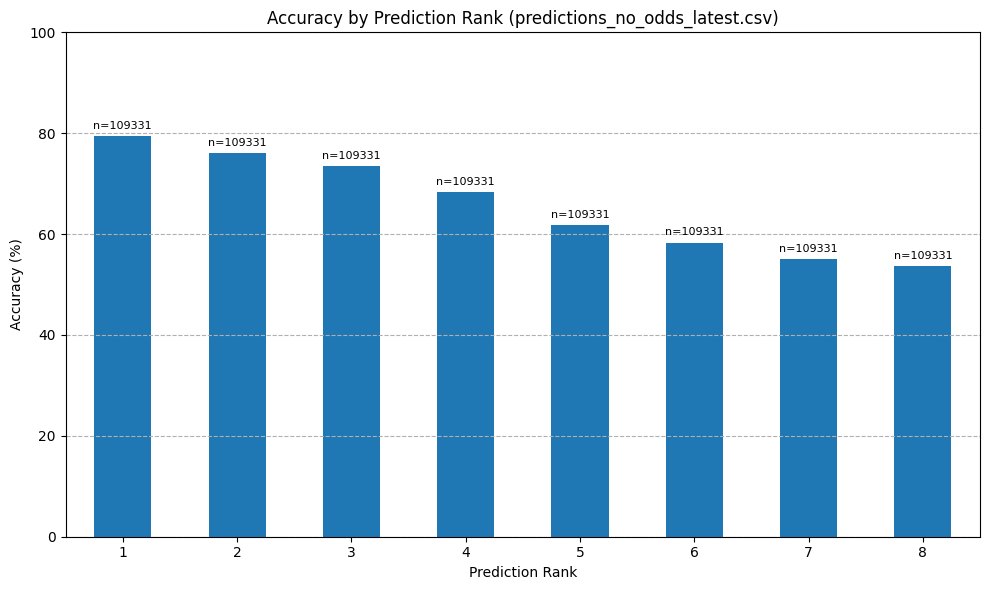

In [9]:
# In[6]:

# --- Calculate Metrics ---
print("\n--- Basic Metrics ---")

if 'df_eval' in locals() and 'IsCorrect' in df_eval.columns:
    # Filter out rows where evaluation wasn't possible (returned NaN)
    df_evaluated = df_eval.dropna(subset=['IsCorrect']).copy()
    print(f"Total predictions evaluated: {len(df_evaluated)} out of {len(df_eval)}")

    if not df_evaluated.empty:
        # Top-1 Accuracy
        top1_preds = df_evaluated[df_evaluated['Rank'] == 1]
        if not top1_preds.empty:
            top1_accuracy = top1_preds['IsCorrect'].mean()
            print(f"Top-1 Prediction Accuracy: {top1_accuracy:.2%}")
        else:
            print("No Rank 1 predictions found after filtering.")

        # Example: Accuracy of Over 2.5 predictions
        over25_preds = df_evaluated[df_evaluated['Outcome'] == '[Over 2.5]']
        if not over25_preds.empty:
            over25_accuracy = over25_preds['IsCorrect'].mean()
            print(f"'[Over 2.5]' Accuracy: {over25_accuracy:.2%}")
            print(f"Number of '[Over 2.5]' predictions evaluated: {len(over25_preds)}")
        else:
            print("'[Over 2.5]' predictions not found or could not be evaluated.")

        # Example: Plot Accuracy by Rank
        print("\n--- Accuracy by Rank ---")
        try:
            plt.figure(figsize=(10, 6))
            # Ensure 'IsCorrect' is numeric (True->1, False->0)
            df_evaluated['IsCorrectNum'] = df_evaluated['IsCorrect'].astype(int)
            accuracy_by_rank = df_evaluated.groupby('Rank')['IsCorrectNum'].mean() * 100
            count_by_rank = df_evaluated.groupby('Rank')['IsCorrectNum'].count()

            # Use the actual filename loaded for the title
            loaded_filename = os.path.basename(EVAL_CSV_PATH) # Get filename from path used in cell [3]
            ax = accuracy_by_rank.plot(kind='bar', title=f'Accuracy by Prediction Rank ({loaded_filename})')

            plt.ylabel('Accuracy (%)')
            plt.xlabel('Prediction Rank')
            plt.ylim(0, max(100, accuracy_by_rank.max() * 1.1)) # Adjust ylim
            plt.xticks(rotation=0)
            plt.grid(axis='y', linestyle='--')

            # Add counts on top of bars
            for i, count in enumerate(count_by_rank):
                 # Ensure index alignment if ranks aren't perfectly 1-8
                 rank_val = accuracy_by_rank.index[i]
                 ax.text(i, accuracy_by_rank.iloc[i] + 1, f'n={count}', ha='center', va='bottom', fontsize=8)

            plt.tight_layout()
            plt.show()
        except Exception as e:
            print(f"Could not generate plot: {e}")

    else:
         print("No predictions could be evaluated (all had missing actual results?).")
else:
     print("ERROR: df_eval or 'IsCorrect' column not found. Run previous cells.")

In [10]:
# In[]: # Add this to a new cell

print("\n--- Accuracy by Outcome Type ---")

if 'df_evaluated' in locals() and not df_evaluated.empty:
    # Calculate accuracy and count for each unique outcome string
    outcome_performance = df_evaluated.groupby('Outcome')['IsCorrectNum'].agg(
        Accuracy='mean',
        Count='size'
    ).reset_index()

    # Convert Accuracy to percentage
    outcome_performance['Accuracy'] *= 100

    # Sort by Accuracy (descending) to see the best performing outcomes
    print("\nTop Performing Outcomes (Sorted by Accuracy):")
    display(outcome_performance.sort_values(by='Accuracy', ascending=False).head(15)) # Show top 15

    # Sort by Count (descending) to see the most frequently predicted outcomes
    print("\nMost Frequent Outcomes Predicted:")
    display(outcome_performance.sort_values(by='Count', ascending=False).head(15)) # Show top 15

    # Optional: Filter for outcomes predicted a minimum number of times for more reliable accuracy stats
    min_predictions_threshold = 1000 # Example threshold
    reliable_performance = outcome_performance[outcome_performance['Count'] >= min_predictions_threshold]
    print(f"\nTop Performing Outcomes (Predicted >= {min_predictions_threshold} times):")
    display(reliable_performance.sort_values(by='Accuracy', ascending=False).head(15))

else:
    print("ERROR: df_evaluated DataFrame not found or empty. Run previous cells.")


--- Accuracy by Outcome Type ---

Top Performing Outcomes (Sorted by Accuracy):


,Outcome,Accuracy,Count
16,[Over 1.5],75.673649,109330
10,[Home Win or Away Win],75.585150,109331
14,[Home Win or Draw],72.166760,96162
22,[Under 3.5],70.904920,102440
0,[Away Win or Draw],64.221322,69329
12,[Home Win or Draw + Over 2.5],63.862661,2330
15,[Home Win],62.284352,28113
9,[Home Win or Away Win + Over 2.5],62.146184,5582
1,[Away Win],61.819549,6650
7,[Goals 2-4],60.718394,105179



Most Frequent Outcomes Predicted:


,Outcome,Accuracy,Count
10,[Home Win or Away Win],75.585150,109331
16,[Over 1.5],75.673649,109330
7,[Goals 2-4],60.718394,105179
22,[Under 3.5],70.904920,102440
14,[Home Win or Draw],72.166760,96162
0,[Away Win or Draw],64.221322,69329
3,[BTTS Yes],53.441545,66598
18,[Over 2.5],57.121552,62360
21,[Under 2.5],54.509955,46863
8,[Goals 3+],59.474725,38951



Top Performing Outcomes (Predicted >= 1000 times):


,Outcome,Accuracy,Count
16,[Over 1.5],75.673649,109330
10,[Home Win or Away Win],75.585150,109331
14,[Home Win or Draw],72.166760,96162
22,[Under 3.5],70.904920,102440
0,[Away Win or Draw],64.221322,69329
12,[Home Win or Draw + Over 2.5],63.862661,2330
15,[Home Win],62.284352,28113
9,[Home Win or Away Win + Over 2.5],62.146184,5582
1,[Away Win],61.819549,6650
7,[Goals 2-4],60.718394,105179
